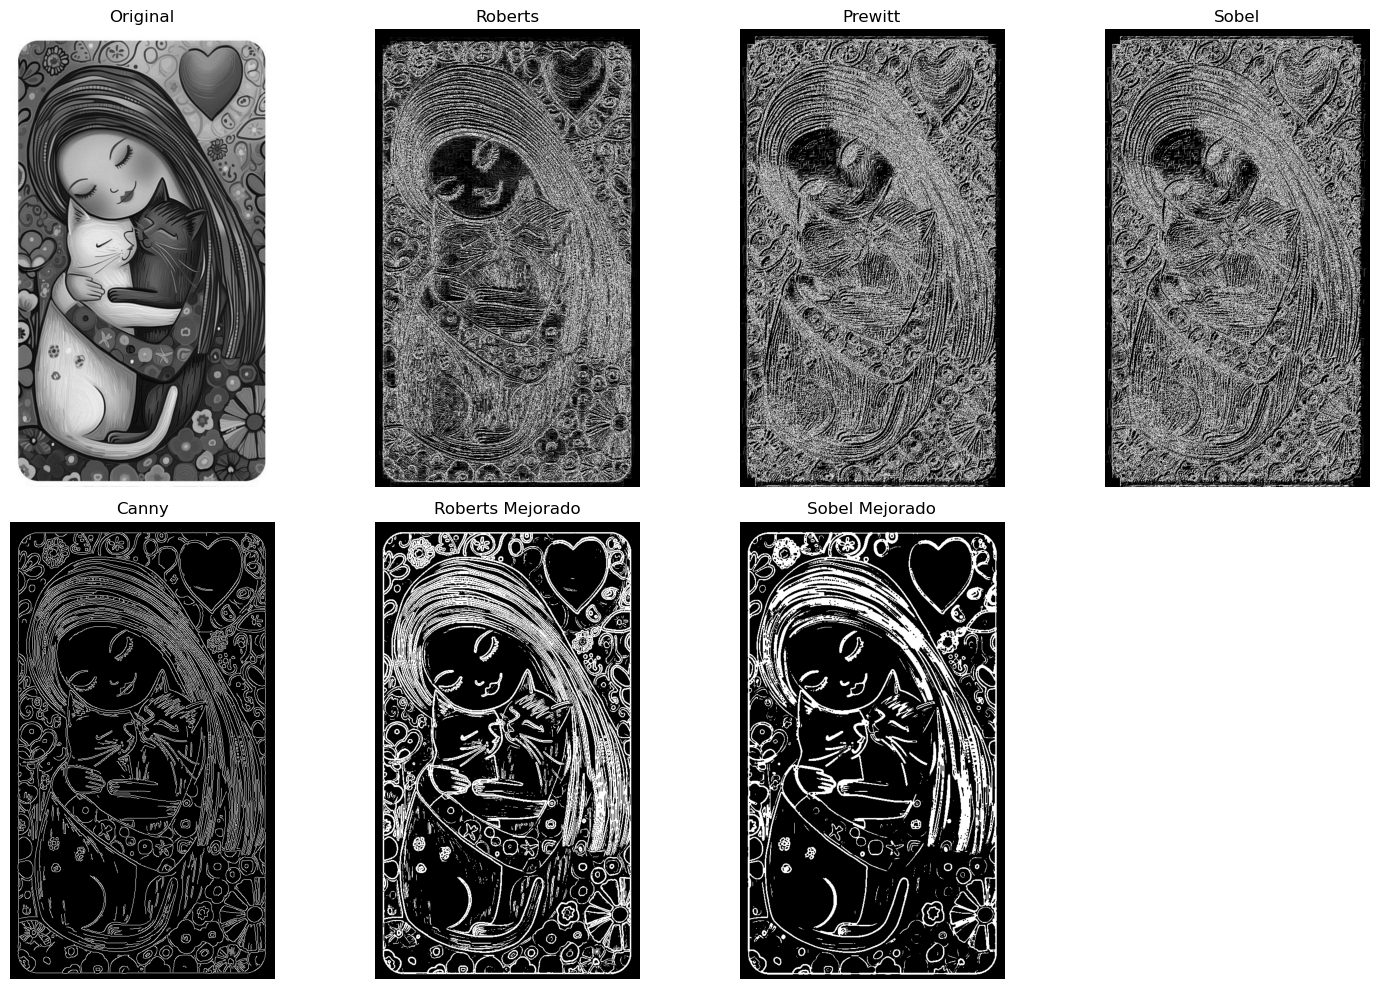

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('1.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Filtro Roberts
robertsx = np.array([[-1, 0], [0, 1]])
robertsy = np.array([[0, -1], [1, 0]])

img_robx = cv2.filter2D(img_gray, -1, robertsx)
img_roby = cv2.filter2D(img_gray, -1, robertsy)
rob_gMagnitud = np.sqrt(img_robx**2 + img_roby**2)
rob_gMagnitud = np.uint8(rob_gMagnitud)

# Filtro Prewitt
prewittx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
prewitty = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

img_prewx = cv2.filter2D(img_gray, -1, prewittx)
img_prewy = cv2.filter2D(img_gray, -1, prewitty)
prew_mag = np.sqrt(img_prewx**2 + img_prewy**2)
prew_mag = np.uint8(prew_mag)


# Filtro Sobel
sobelx = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
sobely = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

sobx_imge = cv2.filter2D(img_gray, -1, sobelx)
soby_imge = cv2.filter2D(img_gray, -1, sobely)
sobel_grad = np.sqrt(sobx_imge**2 + soby_imge**2)
sobel_grad = np.uint8(sobel_grad)


# Filtro Canny
canny = cv2.Canny(img_gray, 100, 200)

# Roberts mejorado
def roberts_mejorado(imagen):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)

    kernelx = np.array([[2, 0], [0, -2]], dtype=np.float32)
    kernely = np.array([[0, 2], [-2, 0]], dtype=np.float32)

    robx = cv2.filter2D(suavizado, cv2.CV_64F, kernelx)
    roby = cv2.filter2D(suavizado, cv2.CV_64F, kernely)

    roberts = cv2.addWeighted(np.abs(robx), 0.7, np.abs(roby), 0.7, 0)
    _, bordes = cv2.threshold(np.uint8(roberts), 30, 255, cv2.THRESH_BINARY)
    return bordes


# Sobel mejorado
def sobel_mejorado(imagen, tam_kernel=3, umbral=30):
    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)

    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=tam_kernel)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=tam_kernel)

    magnitud = np.sqrt(sobelx**2 + sobely**2)
    magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel_morf = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morf)
    return bordes

# Aplicar filtros mejorados
roberts_better = roberts_mejorado(img)
sobel_better = sobel_mejorado(img)


# Mostrar resultados
titles = ['Original', 'Roberts', 'Prewitt', 'Sobel', 'Canny', 'Roberts Mejorado', 'Sobel Mejorado']
images = [img_gray, rob_gMagnitud, prew_mag, sobel_grad, canny, roberts_better, sobel_better]

plt.figure(figsize=(15, 10))
for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
